# W2M5 - Sentiment Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wordcloud
from collections import Counter
import re
import random

import nltk
from nltk.corpus import stopwords

In [2]:
# 일관된 샘플링을 위한 시드 고정
SEED = 42
random.seed(SEED)

## Data Load

In [3]:
# 원본 .csv 파일에 열이름이 없어 Kaggle 사이트를 참고하여 열이름 삽입
columns_name = ["target", "ids", "date", "flag", "user", "text"]
df = pd.read_csv("./training.1600000.processed.noemoticon.csv", encoding="latin1", header=None, names=columns_name)
df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


## EDA

In [4]:
df["target"].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

- Label은 0(=negative)과 4(=positive)가 50:50으로 나뉘어져있음

In [5]:
df["text"][:30]

0     @switchfoot http://twitpic.com/2y1zl - Awww, t...
1     is upset that he can't update his Facebook by ...
2     @Kenichan I dived many times for the ball. Man...
3       my whole body feels itchy and like its on fire 
4     @nationwideclass no, it's not behaving at all....
5                         @Kwesidei not the whole crew 
6                                           Need a hug 
7     @LOLTrish hey  long time no see! Yes.. Rains a...
8                  @Tatiana_K nope they didn't have it 
9                             @twittera que me muera ? 
10          spring break in plain city... it's snowing 
11                           I just re-pierced my ears 
12    @caregiving I couldn't bear to watch it.  And ...
13    @octolinz16 It it counts, idk why I did either...
14    @smarrison i would've been the first, but i di...
15    @iamjazzyfizzle I wish I got to watch it with ...
16    Hollis' death scene will hurt me severely to w...
17                                 about to file

- text들은 특수문자나 기타 사용자 언급(@Nickname), url 주소 등이 포함되어 있음
- 분석에 필요없는 것들은 제거한 뒤 단어들을 추출해야 함

## Text Cleaning

In [6]:
df["clean_text"] = df["text"].copy()
# URL 제거
df["clean_text"] = df["clean_text"].str.replace(r'http\S+|www\.\S+', '', regex=True)
# 멘션 제거 (@username)
df["clean_text"] = df["clean_text"].str.replace(r'@\w+', '', regex=True)
# 해시태그 # 기호 제거 (그 내용들도 분석에 쓰일 것 같아 기호만 남김)
df["clean_text"] = df["clean_text"].str.replace('#', '', regex=False)
# 숫자 제거
df["clean_text"] = df["clean_text"].str.replace(r'\d+', '', regex=True)
# 특수문자 제거 (알파벳, 공백만 남김)
df["clean_text"] = df["clean_text"].str.replace(r'[^a-zA-Z\s]', '', regex=True)
# 여러 공백 정리
df["clean_text"] = df["clean_text"].str.replace(r'\s+', ' ', regex=True).str.strip()
# 소문자 변환
df["clean_text"] = df["clean_text"].str.lower()

In [7]:
# cleaning한 text를 split해서 단어화
df["tokens"] = df["clean_text"].str.split()

In [ ]:
# stopwords - 분석에 큰 의미가 없는 단어 제거
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df["tokens_clean"] = [[word for word in tokens if word not in stop_words] for tokens in df["tokens"]]

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df

,target,ids,date,flag,user,text,clean_text,tokens,tokens_clean
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...,"[awww, thats, a, bummer, you, shoulda, got, da...","[awww, thats, bummer, shoulda, got, david, car..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,"[is, upset, that, he, cant, update, his, faceb...","[upset, cant, update, facebook, texting, might..."
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,"[i, dived, many, times, for, the, ball, manage...","[dived, many, times, ball, managed, save, rest..."
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,"[my, whole, body, feels, itchy, and, like, its...","[whole, body, feels, itchy, like, fire]"
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,"[no, its, not, behaving, at, all, im, mad, why...","[behaving, im, mad, cant, see]"
...,...,...,...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...,just woke up having no school is the best feel...,"[just, woke, up, having, no, school, is, the, ...","[woke, school, best, feeling, ever]"
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...,thewdbcom very cool to hear old walt interviews,"[thewdbcom, very, cool, to, hear, old, walt, i...","[thewdbcom, cool, hear, old, walt, interviews]"
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...,are you ready for your mojo makeover ask me fo...,"[are, you, ready, for, your, mojo, makeover, a...","[ready, mojo, makeover, ask, details]"
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...,happy th birthday to my boo of alll time tupac...,"[happy, th, birthday, to, my, boo, of, alll, t...","[happy, th, birthday, boo, alll, time, tupac, ..."


## Make WordCloud

In [10]:
def sample_words(word_list, sample_size=20000):
    return random.sample(word_list, sample_size) if len(word_list) > sample_size else word_list

In [11]:
# Positive 단어 샘플링
all_words_in_positive = [word for tokens in df[df["target"] == 4]["tokens_clean"] for word in tokens]
word_freq_pos = Counter(all_words_in_positive)
print("Positive 상위 40개 단어:")
print(word_freq_pos.most_common(40))

sampled_pos = sample_words(all_words_in_positive, sample_size=20000)
text_pos = ' '.join(sampled_pos)
wc_positive = wordcloud.WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text_pos)

Positive 상위 40개 단어:
[('im', 75272), ('good', 60869), ('love', 46857), ('day', 45336), ('like', 37116), ('get', 36224), ('thanks', 33750), ('lol', 33511), ('going', 30650), ('u', 30354), ('time', 29348), ('today', 28430), ('go', 27818), ('got', 27801), ('new', 26645), ('one', 25840), ('see', 25468), ('know', 25282), ('great', 24886), ('well', 24564), ('back', 23466), ('night', 22209), ('dont', 22148), ('amp', 22123), ('haha', 20795), ('happy', 20128), ('morning', 20005), ('think', 19350), ('cant', 19127), ('work', 18779), ('hope', 18701), ('twitter', 18479), ('really', 18334), ('fun', 18066), ('ill', 17689), ('thats', 17544), ('much', 16774), ('nice', 16631), ('oh', 16549), ('thank', 15406)]


In [12]:
# Negative 단어 샘플링
all_words_in_negative = [word for tokens in df[df["target"] == 0]["tokens_clean"] for word in tokens]
word_freq_neg = Counter(all_words_in_negative)
print("\nNegative 상위 40개 단어:")
print(word_freq_neg.most_common(40))

sampled_neg = sample_words(all_words_in_negative, sample_size=20000)
text_neg = ' '.join(sampled_neg)
wc_negative = wordcloud.WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text_neg)


Negative 상위 40개 단어:
[('im', 103129), ('get', 45379), ('go', 45164), ('dont', 45158), ('work', 44044), ('cant', 43766), ('like', 40665), ('day', 39482), ('today', 36209), ('going', 33450), ('got', 33102), ('back', 32525), ('really', 31230), ('miss', 30506), ('want', 29737), ('still', 28765), ('good', 28555), ('sad', 27151), ('time', 26779), ('one', 26366), ('know', 25930), ('home', 23791), ('u', 22730), ('last', 22162), ('need', 22055), ('wish', 21994), ('feel', 21807), ('think', 21705), ('lol', 21704), ('oh', 21572), ('bad', 21364), ('see', 20376), ('sorry', 20321), ('didnt', 20006), ('well', 19893), ('much', 19776), ('night', 19199), ('amp', 18613), ('tomorrow', 18459), ('sleep', 17782)]


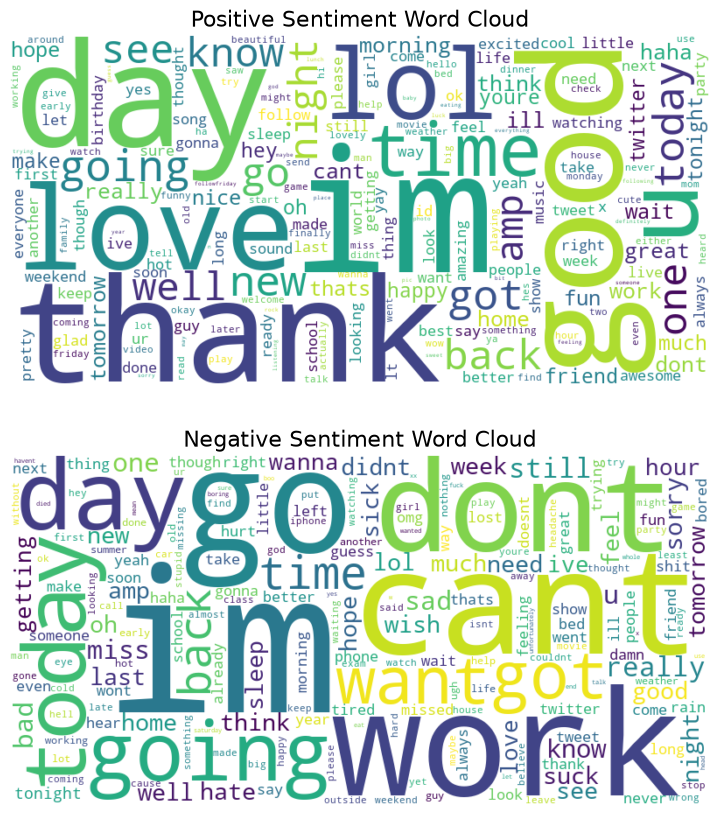

In [14]:
# 시각화
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Sentiment Word Cloud', fontsize=16)

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Sentiment Word Cloud', fontsize=16)

plt.show()